## 5. 特征缩放与学习率 20-23

### 这一节要解决什么问题？

在多变量线性回归中，不同特征的数值范围可能差别很大。

例如房价预测数据中：

* 面积：几百到几千
* 卧室数：个位数
* 楼层数：个位数
* 房龄：几十

如果直接使用原始数据进行梯度下降，会出现一个问题：

> 数值大的特征会对梯度产生很大影响，导致梯度下降变慢，甚至需要非常小的学习率才能稳定训练。

所以这一节要解决两个问题：

> 如何通过特征缩放，让不同特征的数值范围更接近？
> 如何选择合适的学习率 $\alpha$，让梯度下降既稳定又快速？

---

### 核心公式 / 核心概念

#### 1. 特征大小和参数大小的关系

在多变量线性回归中，不同特征的数值范围可能差别很大。

例如：

* 面积 size in feet²：可能是几百到几千
* 卧室数量 bedrooms：可能只是 1 到 5

模型预测公式是：

$$
f_{\vec{w},b}(\vec{x})=w_1x_1+w_2x_2+\cdots+w_nx_n+b
$$

如果某个特征 $x_j$ 的数值很大，那么为了让 $w_jx_j$ 这一项不要过大，它对应的参数 $w_j$ 往往会比较小。

如果某个特征 $x_j$ 的数值很小，那么它对应的参数 $w_j$ 可能会比较大。

但这会导致成本函数 $J(\vec{w},b)$ 的等高线被拉得很长、很窄，梯度下降时路径容易来回震荡，收敛速度变慢。

---

#### 2. 特征缩放的作用

特征缩放的作用是：

> 把不同范围的特征变到差不多的尺度，使梯度下降更快、更稳定。

例如原始数据：

$$
x_1=2104,\quad x_2=5,\quad x_3=1,\quad x_4=45
$$

这些特征数值差距很大。

缩放后，它们会变成比较接近的范围，例如：

$$
x_1 \approx 1.26,\quad x_2 \approx 1.34,\quad x_3 \approx -0.71,\quad x_4 \approx 1.22
$$

这样梯度下降更新参数时会更平衡。

---

#### 3. 均值归一化 / Z-score 标准化

本节常用的特征缩放方法是 Z-score 标准化：

$$
x_j^{norm}=\frac{x_j-\mu_j}{\sigma_j}
$$

其中：

* $x_j$：第 $j$ 个特征的原始值
* $\mu_j$：第 $j$ 个特征的平均值 (i是行代表每套房子，j是列代表每种类型的特征值)
* $\sigma_j$：第 $j$ 个特征的标准差，标准差公式如下：
$\sigma_j=\sqrt{\frac{1}{m}\sum_{i=0}^{m-1}(x_j^{(i)}-\mu_j)^2} $

* $x_j^{norm}$：缩放后的特征值

简单理解：

> 每个特征都减去自己的平均值，再除以自己的标准差。

这样处理后，每个特征大致都会变到相近范围。

---

##### 4. 自动判断梯度下降是否收敛(是否到达合适位置)

注：通常观察曲线就行

除了观察j(w,b)学习曲线，也可以用一个很小的阈值 $\epsilon$ 来自动判断梯度下降是否收敛。

例如设定：

$$
\epsilon = 10^{-3}=0.001
$$

如果相邻两次迭代之间，成本函数的下降量非常小：

$$
J_{old}-J_{new} \leq \epsilon
$$

就可以认为梯度下降已经基本收敛。

其中：

* $J_{old}$：上一次迭代的成本函数值
* $J_{new}$：当前这一次迭代的成本函数值
* $\epsilon$：人为设定的很小的阈值

简单理解：

> 如果继续迭代时，Cost 每次只下降一点点，几乎不再变化，就说明模型已经接近最优解，可以认为梯度下降基本收敛。

---

#### 5. 学习率 $\alpha$ 的作用

梯度下降更新参数的公式仍然是：

$$
w_j = w_j - \alpha \frac{\partial J(\vec{w},b)}{\partial w_j}
$$

$$
b = b - \alpha \frac{\partial J(\vec{w},b)}{\partial b}
$$

其中 $\alpha$ 是学习率。

学习率的作用是：控制每次更新参数时走多大一步。

如果学习率太小：Cost 会下降得很慢，训练速度慢。

如果学习率太大：Cost 可能不下降，甚至越来越大，说明梯度下降发散了。

合适的学习率应该满足：

> Cost 随着迭代次数增加而不断下降，并且下降速度较快。

---

### 代码如下：


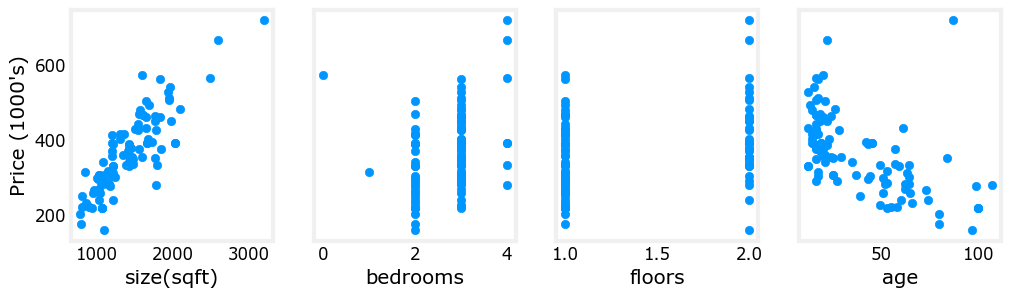

In [1]:
"""
1,导包
"""
import numpy as np
np.set_printoptions(precision=2) #设置 NumPy 数组打印时只显示 2 位小数
import matplotlib.pyplot as plt
#设置后面画图时要用到的颜色
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0'; 
# 使用课程提供的 matplotlib 画图样式文件
plt.style.use('./deeplearning.mplstyle')
from lab_utils_multi import  load_house_data, compute_cost, run_gradient_descent 
from lab_utils_multi import  norm_plot, plt_contour_multi, plt_equal_scale, plot_cost_i_w

""" 
2,加载数据集
"""
X_train, y_train = load_house_data()
# 为每一列特征起的名字
X_features = ['size(sqft)','bedrooms','floors','age']

"""
3,画出每个特征和房价的关系
    作用：
    分别观察面积、卧室数、楼层数、房龄和房价之间的关系。
"""
# 创建 1 行 4 列的子图
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
# 循环画出每一个特征和房价的散点图
for i in range(len(ax)):

    # X_train[:, i] 表示取出第i个特征的所有数据，y_train 表示所有房子的真实价格
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i]) # 设置每个子图的横坐标名称
ax[0].set_ylabel("Price (1000's)") # 设置第一个子图的纵坐标名称
plt.show()


Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 9.55884e+04  5.5e-01  1.0e-03  5.1e-04  1.2e-02  3.6e-04 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 1.28213e+05 -8.8e-02 -1.7e-04 -1.0e-04 -3.4e-03 -4.8e-05  6.4e+05  1.2e+03  6.2e+02  1.6e+04  4.1e+02
        2 1.72159e+05  6.5e-01  1.2e-03  5.9e-04  1.3e-02  4.3e-04 -7.4e+05 -1.4e+03 -7.0e+02 -1.7e+04 -4.9e+02
        3 2.31358e+05 -2.1e-01 -4.0e-04 -2.3e-04 -7.5e-03 -1.2e-04  8.6e+05  1.6e+03  8.3e+02  2.1e+04  5.6e+02
        4 3.11100e+05  7.9e-01  1.4e-03  7.1e-04  1.5e-02  5.3e-04 -1.0e+06 -1.8e+03 -9.5e+02 -2.3e+04 -6.6e+02
        5 4.18517e+05 -3.7e-01 -7.1e-04 -4.0e-04 -1.3e-02 -2.1e-04  1.2e+06  2.1e+03  1.1e+03  2.8e+04  7.5e+02
        6 5.63212e+05  9.7e-01  1.7e-03  8.7e-04  1.8e-02  6.6e-04 -1.3e+06 -2.5e+03 -1.3e+03 -3.1e+04 -

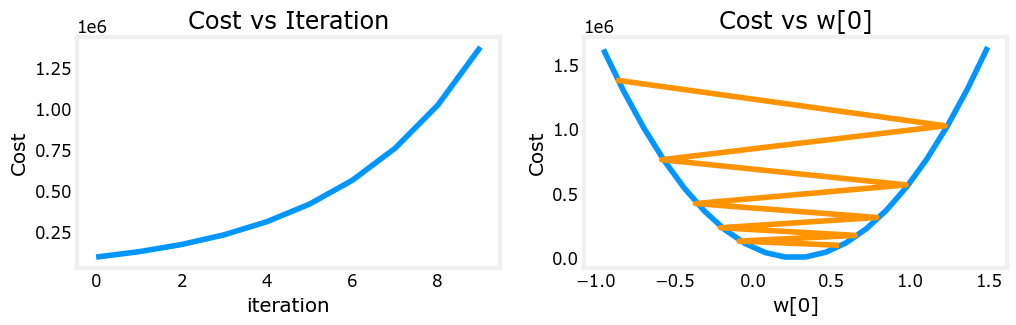

In [2]:
""" 
4,学习率
"""

#设置学习率(稍大)
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 9.9e-7)
plot_cost_i_w(X_train,y_train,hist)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 4.42313e+04  5.5e-02  1.0e-04  5.2e-05  1.2e-03  3.6e-05 -5.5e+05 -1.0e+03 -5.2e+02 -1.2e+04 -3.6e+02
        1 2.76461e+04  9.8e-02  1.8e-04  9.2e-05  2.2e-03  6.5e-05 -4.3e+05 -7.9e+02 -4.0e+02 -9.5e+03 -2.8e+02
        2 1.75102e+04  1.3e-01  2.4e-04  1.2e-04  2.9e-03  8.7e-05 -3.4e+05 -6.1e+02 -3.1e+02 -7.3e+03 -2.2e+02
        3 1.13157e+04  1.6e-01  2.9e-04  1.5e-04  3.5e-03  1.0e-04 -2.6e+05 -4.8e+02 -2.4e+02 -5.6e+03 -1.8e+02
        4 7.53002e+03  1.8e-01  3.3e-04  1.7e-04  3.9e-03  1.2e-04 -2.1e+05 -3.7e+02 -1.9e+02 -4.2e+03 -1.4e+02
        5 5.21639e+03  2.0e-01  3.5e-04  1.8e-04  4.2e-03  1.3e-04 -1.6e+05 -2.9e+02 -1.5e+02 -3.1e+03 -1.1e+02
        6 3.80242e+03  2.1e-01  3.8e-04  1.9e-04  4.5e-03  1.4e-04 -1.3e+05 -2.2e+02 -1.1e+02 -2.3e+03 -

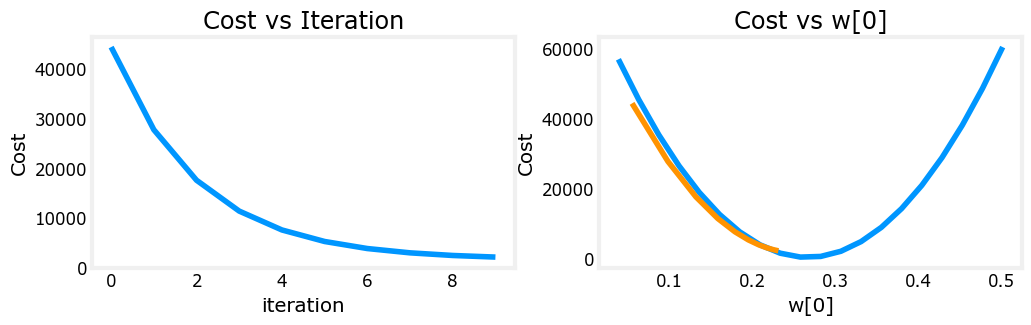

In [3]:
#设置学习率(较小)
_, _, hist = run_gradient_descent(X_train, y_train, 10, alpha = 1e-7)
plot_cost_i_w(X_train,y_train,hist)

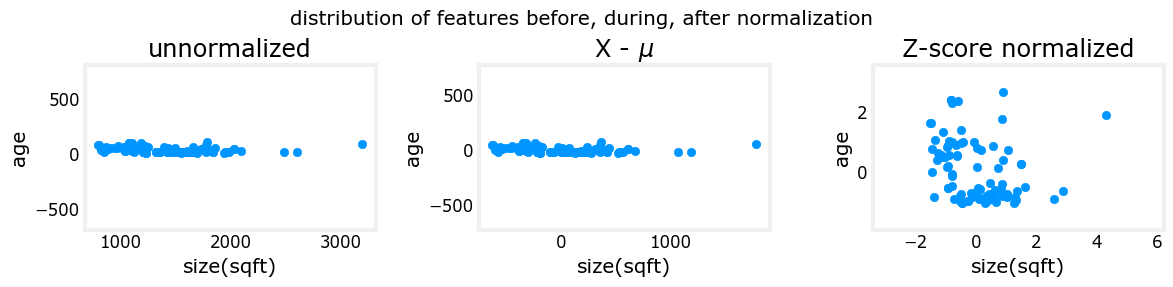

In [5]:
""" 
5,特征缩放，定义 Z-score 特征缩放函数
    对每一列特征进行标准化，让不同特征的数值范围更接近。
"""
def zscore_normalize_features(X):
    """
    对 X 的每一列特征进行 Z-score 标准化
    参数: X: 原始训练数据，形状为 (m, n) m表示样本数量, n表示特征数量
    """
    mu = np.mean(X, axis=0) # 计算每一列特征的平均值
    sigma = np.std(X, axis=0) # 计算每一列特征的标准差
    X_norm = (X - mu) / sigma # 对每一列特征进行标准化

    #X_norm:标准化后的数据,mu:每一列特征的平均值, sigma:每一列特征的标准差
    return X_norm, mu, sigma
    
"""
6,展示 Z-score 标准化过程
    观察原始数据、减去均值后的数据、标准化后的数据分别是什么样子。
"""

X_norm, mu, sigma = zscore_normalize_features(X_train) # 调用上面定义好的函数，真正完成标准化
X_mean = X_train - mu # 为了画中间过程，单独计算“减去均值后”的数据


fig, ax = plt.subplots(1, 3, figsize=(12, 3)) # 画图观察标准化前、中、后的变化

# 左图：原始数据
ax[0].scatter(X_train[:, 0], X_train[:, 3])
ax[0].set_xlabel(X_features[0])
ax[0].set_ylabel(X_features[3])
ax[0].set_title("unnormalized")
ax[0].axis('equal')

# 中图：减去均值后的数据
ax[1].scatter(X_mean[:, 0], X_mean[:, 3])
ax[1].set_xlabel(X_features[0])
ax[1].set_ylabel(X_features[3])
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

# 右图：Z-score 标准化后的数据
ax[2].scatter(X_norm[:, 0], X_norm[:, 3])
ax[2].set_xlabel(X_features[0])
ax[2].set_ylabel(X_features[3])
ax[2].set_title("Z-score normalized")
ax[2].axis('equal')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()



In [ ]:
"""
7,对训练数据进行特征缩放
    并比较缩放前后的范围
"""

# 调用前面定义好的函数，对原始训练数据 X_train 进行标准化
# X_norm：标准化后的训练数据
# X_mu：每一列特征的平均值
# X_sigma：每一列特征的标准差
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)


print(f"X_mu = {X_mu}") # 打印每个特征的平均值
print(f"X_sigma = {X_sigma}") # 打印每个特征的标准差

# np.ptp() 用来计算最大值和最小值的差，某一列可能范围很大，某一列可能很小
# axis=0 表示按列计算，也就是分别计算每一个特征的范围
print(f"Peak to Peak range by column in Raw        X: {np.ptp(X_train, axis=0)}")

# 计算标准化后每一列特征的范围
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis=0)}")

X_mu = [1.42e+03 2.72e+00 1.38e+00 3.84e+01]
X_sigma = [411.62   0.65   0.49  25.78]
Peak to Peak range by column in Raw        X: [2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X: [5.85 6.14 2.06 3.69]


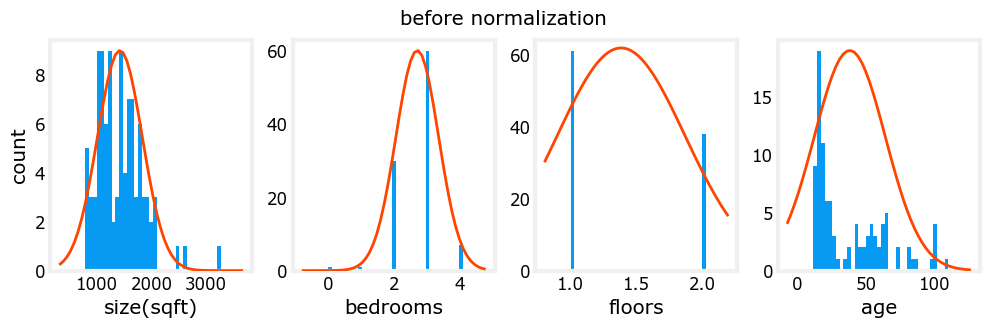

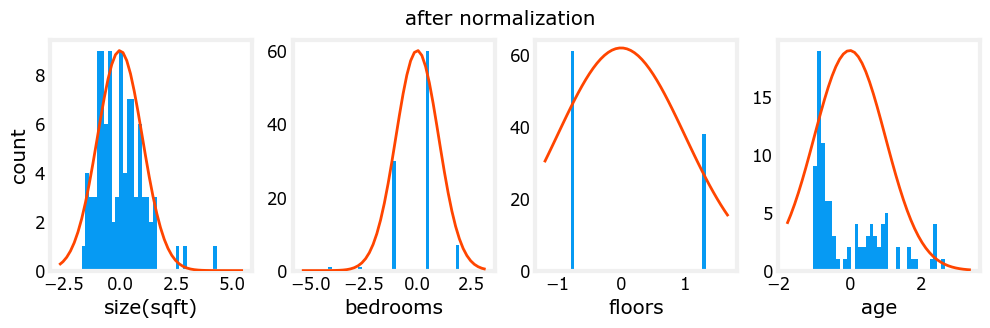

In [ ]:
"""
8,画出标准化前后的特征分布
    作用：
    对比每个特征在标准化前后的范围变化。
    
    上一部分是用数字比较范围；
    这一部分是用图像观察每个特征的分布。
"""

# 画出标准化前的特征分布
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for i in range(len(ax)):  
    norm_plot(ax[i], X_train[:, i]) # X_train[:, i] 表示取出第 i 个特征的所有数据
    ax[i].set_xlabel(X_features[i]) # 给每个子图设置横坐标名称

ax[0].set_ylabel("count") # 设置第一个子图的纵坐标名称
fig.suptitle(" before normalization") # 设置整张图的标题
plt.show() # 显示图像


# 画出标准化后的特征分布
fig, ax = plt.subplots(1, 4, figsize=(12, 3))

for i in range(len(ax)):   
    norm_plot(ax[i], X_norm[:, i]) # X_norm[:, i] 表示取出标准化后第 i 个特征的所有数据
    ax[i].set_xlabel(X_features[i]) # 给每个子图设置横坐标名称

ax[0].set_ylabel("count") # 设置第一个子图的纵坐标名称
fig.suptitle("after normalization") # 设置整张图的标题
plt.show() # 显示图像

""" 
标准化不会改变数据之间的相对关系。它只是把横坐标范围缩小了
蓝色柱子：某个范围内有多少个样本，纵坐标 count 表示数量。
橙色曲线可以理解成辅助观察分布形状的曲线，不是重点

"""

In [ ]:
"""
9,使用标准化后的数据运行梯度下降
    作用：
    用标准化后的 X_norm 训练模型。
    因为特征已经缩放到相近范围，所以可以使用更大的学习率 alpha。
    让 Cost 更快下降，从而更快得到合适的 w 和 b。
"""

# 使用标准化后的数据运行梯度下降
# 参数解释：
# X_norm：标准化后的训练数据
# y_train：真实房价
# 1000：迭代次数
# 1.0e-1：学习率 alpha，也就是 0.1
w_norm, b_norm, hist = run_gradient_descent(X_norm, y_train, 1000, 1.0e-1)

Iteration Cost          w0       w1       w2       w3       b       djdw0    djdw1    djdw2    djdw3    djdb  
---------------------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
        0 5.76170e+04  8.9e+00  3.0e+00  3.3e+00 -6.0e+00  3.6e+01 -8.9e+01 -3.0e+01 -3.3e+01  6.0e+01 -3.6e+02
      100 2.21086e+02  1.1e+02 -2.0e+01 -3.1e+01 -3.8e+01  3.6e+02 -9.2e-01  4.5e-01  5.3e-01 -1.7e-01 -9.6e-03
      200 2.19209e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.0e-02  1.5e-02  1.7e-02 -6.0e-03 -2.6e-07
      300 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.0e-03  5.1e-04  5.7e-04 -2.0e-04 -6.9e-12
      400 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.4e-05  1.7e-05  1.9e-05 -6.6e-06 -2.7e-13
      500 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -1.1e-06  5.6e-07  6.2e-07 -2.2e-07 -2.6e-13
      600 2.19207e+02  1.1e+02 -2.1e+01 -3.3e+01 -3.8e+01  3.6e+02 -3.7e-08  1.9e-08  2.1e-08 -7.3e-09 -

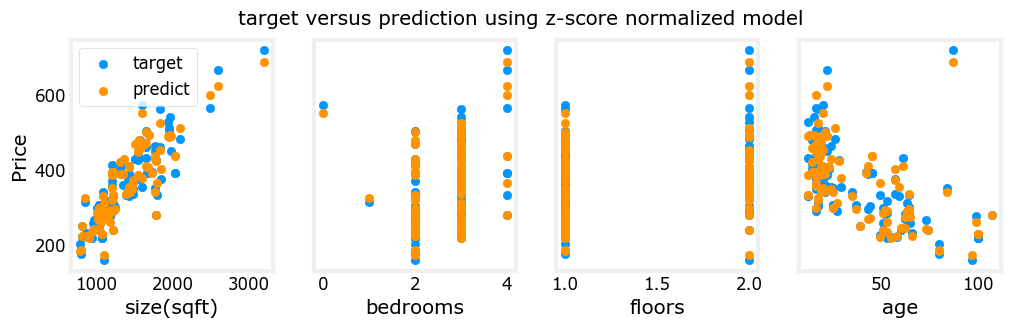

In [ ]:
"""
10,预测训练集，并与真实房价对比
    作用：
    使用训练好的 w_norm 和 b_norm，对训练集中的房子进行预测，
    然后画出预测值和真实值的对比图。
"""


m = X_norm.shape[0] # 获取训练样本数量，X_norm.shape[0] 表示有多少套房子
yp = np.zeros(m) # 创建一个全 0 数组，用来保存每一套房子的预测价格

# 使用标准化后的特征进行预测
for i in range(m):
    yp[i] = np.dot(X_norm[i], w_norm) + b_norm #X_norm[i]用的是标准化后的特征

fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)

for i in range(len(ax)): # 依次画出每个特征下(原始特征)，真实值和预测值的对比
    ax[i].scatter(X_train[:, i], y_train, label='target') # 画真实房价
    ax[i].scatter(X_train[:, i], yp, color=dlorange, label='predict') # 画预测房价
    ax[i].set_xlabel(X_features[i]) # 设置横坐标名称

ax[0].set_ylabel("Price") # 设置纵坐标名称
ax[0].legend() # 显示图例
fig.suptitle("target versus prediction using z-score normalized model") # 设置整张图标题
plt.show()

In [15]:
"""
11,预测一套新房子的价格
    作用：
    使用训练好的 w_norm 和 b_norm，
    预测一套新的房子的价格。

    注意：
    因为模型是用标准化后的 X_norm 训练的，
    所以新房子的数据也必须用同样的 X_mu 和 X_sigma 标准化。
"""

# 新房子的原始特征
# 含义：面积 1200 平方英尺，3 个卧室，1 层楼，40 年房龄
x_house = np.array([1200, 3, 1, 40])

# 对新房子进行标准化
# 注意：
# 这里必须使用训练集的平均值 X_mu 和标准差 X_sigma
# 不能重新用 x_house 自己去算平均值和标准差
#因为 w_norm 和 b_norm 是用标准化后的数据训练出来的。
x_house_norm = (x_house - X_mu) / X_sigma
print(f"标准化后的新房子特征：{x_house_norm}") # 打印标准化后的新房子特征

x_house_predict = np.dot(x_house_norm, w_norm) + b_norm # 使用训练好的模型进行预测
# 因为 y_train 的单位是 1000 美元，所以最终结果要乘以 1000
print(f"价格约为{x_house_predict * 1000:0.0f}")

标准化后的新房子特征：[-0.53  0.43 -0.79  0.06]
价格约为318709


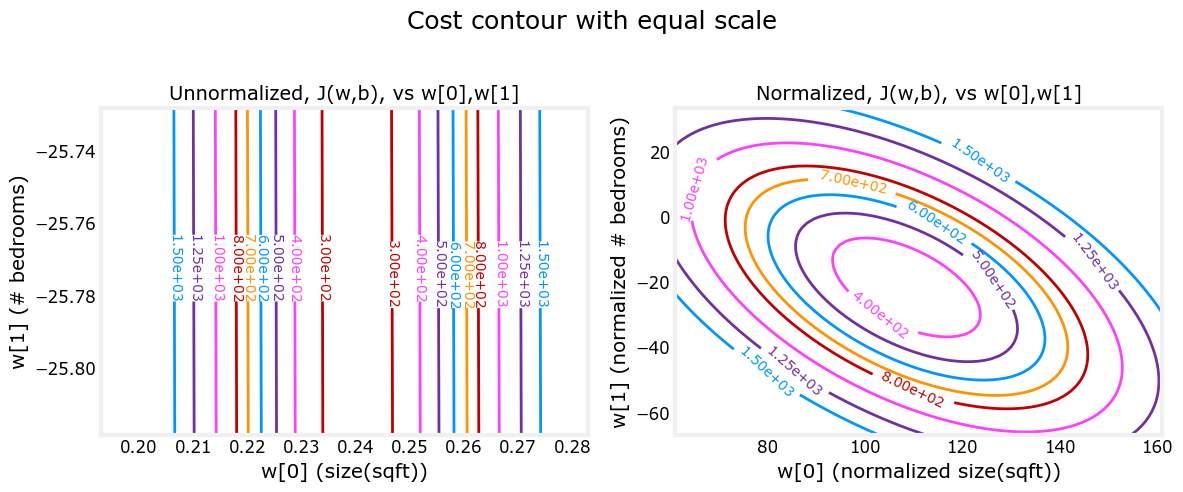

In [16]:
"""
12,画成本等值线
    作用：
    观察特征缩放前后，成本函数等值线形状的变化。

    如果没有特征缩放：
        成本函数等值线可能很细长，梯度下降容易绕来绕去。

    如果进行了特征缩放：
        成本函数等值线会更接近圆形，梯度下降更快、更稳定。
"""

plt_equal_scale(X_train, X_norm, y_train)